<a href="https://colab.research.google.com/github/prishabobde/CS_181_ComputerVision/blob/main/CS181_HW4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 2: Optical Flow Estimation

In [ ]:
import cv2
import numpy as np
from scipy.signal import convolve2d
import os
import matplotlib.pyplot as plt

##1) Preprocessing
- Convert all images to grayscale and scale pixel intensities to [0,1]
- Apply a 5x5 Gaussian blur using the fixed kernel K with any built in convolution function (ex OpenCVfilter2D / scipy convolve2D)


In [ ]:
from google.colab import files
image_01 = files.upload()

Saving image_01.png to image_01 (1).png


In [ ]:
image_02 = files.upload()

Saving image_02.png to image_02.png


In [ ]:
image_03 = files.upload()

Saving image_03.png to image_03.png


In [ ]:
#convert to grayscale
img1 = cv2.imread("image_01.png")
img2 = cv2.imread("image_02.png")
img3 = cv2.imread("image_03.png")

def preprocess(image):    #grascale + normalize
  final = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  final = final.astype(np.float32) / 255.0
  return final

img1 = preprocess(img1)
img2 = preprocess(img2)
img3 = preprocess(img3)

K = np.array([[0.00296902, 0.01330621, 0.02193823, 0.01330621, 0.00296902],
              [0.01330621, 0.05963429, 0.09832033, 0.05963429, 0.01330621],
              [0.02193823, 0.09832033, 0.16210282, 0.09832033, 0.02193823],
              [0.01330621, 0.05963429, 0.09832033, 0.05963429, 0.01330621],
              [0.00296902, 0.01330621, 0.02193823, 0.01330621, 0.00296902]], dtype=np.float32)

#blur
def blur(image):
  return cv2.filter2D(image, -1, K)

img1 = blur(img1)
img2 = blur(img2)
img3 = blur(img3)


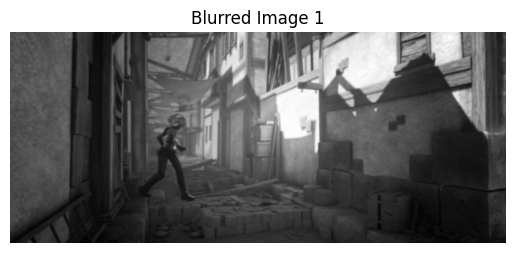

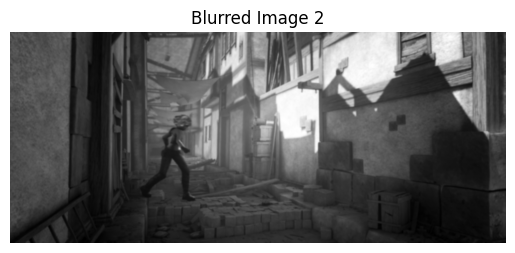

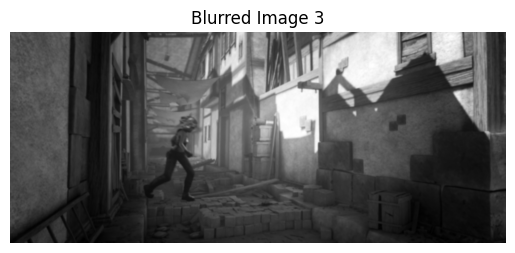

In [ ]:
def printImage(image, title="Image"):
    plt.imshow(image, cmap='gray')  # cmap='gray' for grayscale
    plt.title(title)
    plt.axis('off')  # hide axes
    plt.show()

printImage(img1, "Blurred Image 1")
printImage(img2, "Blurred Image 2")
printImage(img3, "Blurred Image 3")

## 2) Compute Image Derivatives
- Compute spacial gradients Ix and Iy on image_02 (middle frame) using sobel
- Compute temporal derivative at time t

In [ ]:
#sobel
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32)
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32)

Ix = convolve2d(img2, sobel_x, mode='same') #mode = same --> keeps input same
Iy = convolve2d(img2, sobel_y, mode='same')

#temporal derivative
It = (img3 - img1) / 2.0
print("Derivatives:", Ix.shape, Iy.shape, It.shape)


Derivatives: (436, 1024) (436, 1024) (436, 1024)


##3) Estimate Optical Flow
Lucas Kanade
A = structure matrix
b = correlation between spacial and temporal gradients
solve 2x2 system --> local optical flow vector (u,v)


In [ ]:
def lucasKanade(Ix, Iy, It, window_size=7):

  h, w = Ix.shape
  u = np.zeros((h, w), dtype=np.float32)
  v = np.zeros((h, w), dtype=np.float32)
  #half window = 3

  for i in range(3, h - 3):
        for j in range(3, w - 3):
            # Extract 7x7 window around pixel (i, j)
            Ix_win = Ix[i - 3:i + 3 + 1,
                        j - 3:j + 3 + 1]
            Iy_win = Iy[i - 3:i + 3 + 1,
                        j - 3:j + 3 + 1]
            It_win = It[i - 3:i + 3 + 1,
                        j - 3:j + 3 + 1]

            #  windows --> sum summation
            Ix_flat = Ix_win.flatten()
            Iy_flat = Iy_win.flatten()
            It_flat = It_win.flatten()

            # Structure matrix A (2x2)
            A = np.array([
                [np.sum(Ix_flat * Ix_flat), np.sum(Ix_flat * Iy_flat)],
                [np.sum(Ix_flat * Iy_flat), np.sum(Iy_flat * Iy_flat)]
            ], dtype=np.float32)

            #  vector b (2x1)
            b = np.array([
                np.sum(Ix_flat * It_flat),
                np.sum(Iy_flat * It_flat)
            ], dtype=np.float32)

            # next --->  A * [u, v]ᵀ = -b
            # A is invertible (well-conditioned)
            det_A = np.linalg.det(A)

            if abs(det_A) > 1e-6:  # Threshold --> avoid singular matrices
                flow = np.linalg.solve(A, -b)
                u[i, j] = flow[0]
                v[i, j] = flow[1]
            else:
                # A is singular - no reliable flow estimate
                u[i, j] = 0
                v[i, j] = 0
  return u, v

In [ ]:
u, v = lucasKanade(Ix, Iy, It)
print("u shape:", u.shape)
print("v shape:", v.shape)

u shape: (436, 1024)
v shape: (436, 1024)


## 4) Compute Structure Tensor Eigenvalues
Make sure both eigenvalus are sufficiently large to get reliable estimate

In [ ]:
def computeStrucTensorEigens(Ix, Iy):
  h, w = Ix.shape
  lambda1_arr = np.zeros((h, w), dtype=np.float32)
  lambda2_arr = np.zeros((h, w), dtype=np.float32)

  for y in range(3, h - 3):
      for x in range(3, w - 3):
          Ix_win = Ix[y-3:y+3+1, x-3:x+3+1].flatten()
          Iy_win = Iy[y-3:y+3+1, x-3:x+3+1].flatten()

          A = np.array([[np.sum(Ix_win**2), np.sum(Ix_win*Iy_win)],
                          [np.sum(Ix_win*Iy_win), np.sum(Iy_win**2)]], dtype=np.float32)

          eigvals = np.linalg.eigvalsh(A)
          lambda1_arr[y, x] = eigvals[1]  # lambda1> lamb2
          lambda2_arr[y, x] = eigvals[0]

  return lambda1_arr, lambda2_arr

In [ ]:
#apply it
lambda1, lambda2 = computeStrucTensorEigens(Ix, Iy)
lambda_threshold = 0.01 #can change
valid = lambda2 > lambda_threshold

u_valid = u * valid
v_valid = v * valid

##5) Visualization


### 1) Optical Flow (Quiver Plot)

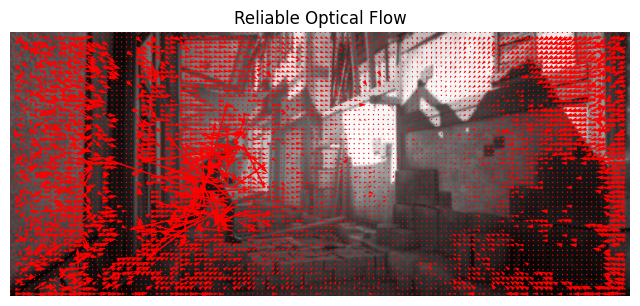

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(img2, cmap='gray')
stride = 8
plt.quiver(np.arange(0, u.shape[1], stride), np.arange(0, u.shape[0], stride),
           u_valid[::stride, ::stride], -v_valid[::stride, ::stride],color='red')
plt.title("Reliable Optical Flow")
plt.axis('off')
plt.show()

### 2) Reliability Map (Eigenvalue Heatmap)


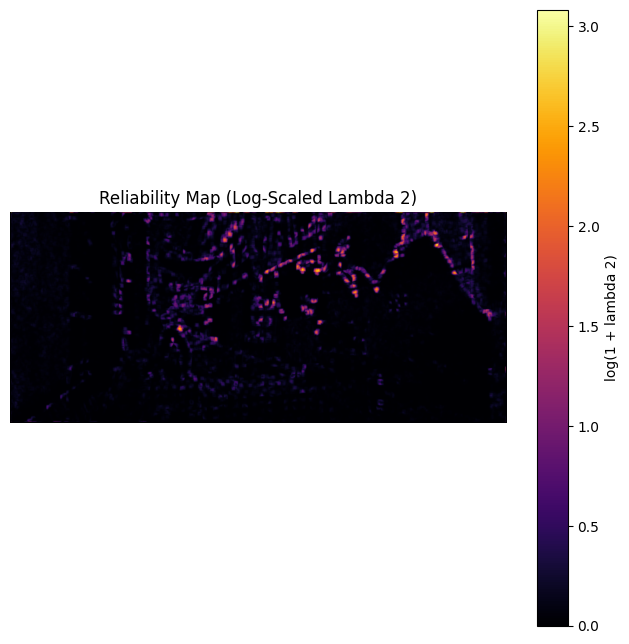

In [ ]:
#normalize for better contrast
lambda2_norm = (lambda2 - np.min(lambda2)) / (np.max(lambda2) - np.min(lambda2))
plt.figure(figsize=(8, 8))
plt.imshow(np.log1p(lambda2), cmap='inferno')  # log1p avoids log(0)
#plt.imshow(lambda2_norm, cmap='inferno')
plt.title("Reliability Map (Log-Scaled Lambda 2)")
plt.colorbar(label="log(1 + lambda 2)")
plt.axis('off')
plt.show()